1. Implementar a mano
    - Pasar a blanco y negro
    - Aplicar filtro gaussiano (práctica 3)
    - Detectar bordes https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
    - Escoger un borde (para esquina Harris)
    - Aplicar una máscara y buscar en ella los cambios de intensidad
    - Sobel para las derivadas
2. Implementar con opencv

https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/

Prueba de bordes con Canny

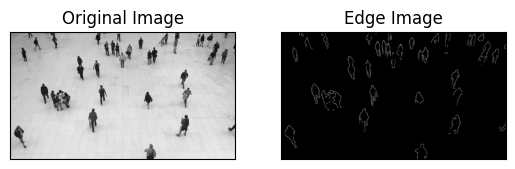

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

#frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")


# crea colores aleatorios
color = np.random.randint(0,255,(100,3))

# toma la primera imagen
status, old_frame = frame.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(old_gray, (7, 7), sigmaX=20)
assert blur is not None, "file could not be read, check with os.path.exists()"
edges = cv2.Canny(blur,100,200)

cv2.imshow("original", old_gray)
 
# Convertimos a escala de grises
gris = cv2.cvtColor(old_gray, cv2.COLOR_BGR2GRAY)
 
# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(gris, (5,5), 0)
 
cv2.imshow("suavizado", gauss)
 
# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
 
cv2.imshow("canny", canny)
 
# Buscamos los contornos
(contornos,_) = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
 
# Mostramos el número de monedas por consola
print("He encontrado {} objetos".format(len(contornos)))
 
cv2.drawContours(old_gray,contornos,-1,(0,0,255), 2)
cv2.imshow("contornos", old_gray)
 
plt.show()



In [ ]:

import numpy as np
import cv2
 
import numpy as np
import cv2
import matplotlib.pyplot as plt

#frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")


# crea colores aleatorios
color = np.random.randint(0,255,(100,3))

# toma la primera imagen
status, old_frame = frame.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imshow("original", old_gray)
 
# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5,5), 0)
 
cv2.imshow("suavizado", gauss)
 
# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
 
cv2.imshow("canny", canny)
 
# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos,_) = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Mostramos el número de objetos detectados
print("He encontrado {} objetos".format(len(contornos)))
 
cv2.drawContours(old_gray,contornos,-1,(0,0,255), 2)
cv2.imshow("contornos", old_gray)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:,:,1].argmin()][0]

import cv2
import numpy as np
# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask

top = (120, 85)  # una coordenada -> TODO buscar esquina (p.e.: Harris)
intensidad_1 = get_mask_5x5(old_gray, top)

print(f"Máscara 5x5:\n{intensidad_1}")

sobelx = cv2.Sobel(gauss, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gauss, cv2.CV_64F, 0, 1, ksize=3)
# https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html
abs_grad_x = cv2.convertScaleAbs(sobelx)
abs_grad_y = cv2.convertScaleAbs(sobely)

print(f"Magnitudes en x:\n{abs_grad_x.ravel()}")
print(f"Magnitudes en y:\n{abs_grad_y.ravel()}")
matrix = np.column_stack((abs_grad_x.ravel(), abs_grad_y.ravel())) # matrix de las derivadas
cv2.waitKey(0)
cv2.destroyAllWindows()

#inicializo una imagen para añadir los resultados en blanco
result2 =  np.zeros_like(old_gray)
int = 0
while status:

  #captura la imagen 2
  ret, img = frame.read()
  if not ret:
    print("No hay más frames o el frame no se pudo leer.")
    break
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  intensidad_2 = get_mask_5x5(gray, top)
  T = intensidad_1 - intensidad_2
  # diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T # Error de dimensiones
  # print(diff_p)
  int +=1
      
    
frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

He encontrado 183 objetos
Máscara 5x5:
[[157 157 157 158 160]
 [157 159 159 160 161]
 [159 161 163 161 163]
 [161 163 163 163 163]
 [164 165 163 163 163]]
Magnitudes en x:
[0 0 0 ... 0 0 0]
Magnitudes en y:
[0 0 0 ... 0 0 0]
No hay más frames o el frame no se pudo leer.
